In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset

from pathlib import Path
import numpy as np
import random
import time
import json

# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ============================================================
# PATHS
# ============================================================

processed_dir = Path("../data/processed")
train_dir = processed_dir / "Training"

results_dir = Path("../results")
checkpoint_dir = results_dir / "checkpoints"
metrics_dir = results_dir / "metrics"

checkpoint_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

# ============================================================
# CONFIGURATION
# ============================================================

BATCH_SIZE = 16
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_CLASSES = 4

CLASS_NAMES = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Classes:", CLASS_NAMES)

Device: cpu
Batch size: 16
Epochs: 10
Learning rate: 0.0001
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [2]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ImageNet normalization — same as previous models
data_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load processed training images
full_train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform
)

# Labels for stratified splitting
targets = np.array(full_train_dataset.targets)
indices = np.arange(len(full_train_dataset))

# Same stratified 80/20 split
train_indices, val_indices = train_test_split(
    indices,
    test_size=0.2,
    random_state=SEED,
    stratify=targets
)

train_dataset = Subset(
    full_train_dataset,
    train_indices
)

val_dataset = Subset(
    full_train_dataset,
    val_indices
)

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Total:", len(train_dataset) + len(val_dataset))
print("Class mapping:", full_train_dataset.class_to_idx)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training images: 4343
Validation images: 1086
Total: 5429
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training batches: 272
Validation batches: 68


In [3]:
# Step 3: Initialize MobileNetV3-Large

# Load pretrained MobileNetV3-Large
weights = models.MobileNet_V3_Large_Weights.DEFAULT
model = models.mobilenet_v3_large(weights=weights)

# Check original classifier
print("Original classifier:")
print(model.classifier)

# Replace the final classification layer
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

# Freeze the entire model first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only the classifier
for param in model.classifier.parameters():
    param.requires_grad = True

# Move model to device
model = model.to(device)

# Count trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("\nMobileNetV3-Large initialized successfully.")
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

# Verify output shape with a dummy input
dummy_input = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    output = model(dummy_input)

print("Output shape:", output.shape)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to C:\Users\Kanak/.cache\torch\hub\checkpoints\mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:06<00:00, 3.44MB/s]


Original classifier:
Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)

MobileNetV3-Large initialized successfully.
Total parameters: 4207156
Trainable parameters: 1235204
Output shape: torch.Size([1, 4])


In [4]:
# Step 4: Train MobileNetV3-Large

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0
best_epoch = 0

checkpoint_path = checkpoint_dir / "mobilenet_v3_large_best.pth"
history_path = metrics_dir / "mobilenet_v3_large_training_history.json"

print("Starting MobileNetV3-Large training...")
print("-" * 70)

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    # Store history
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f} | "
        f"Time: {epoch_time / 60:.2f} min"
    )

    # Save best model
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1

        torch.save({
            "model_name": "MobileNetV3-Large",
            "model_state_dict": model.state_dict(),
            "class_to_idx": train_dataset.dataset.class_to_idx
                if hasattr(train_dataset, "dataset")
                else train_dataset.class_to_idx,
            "best_val_accuracy": best_val_accuracy,
            "epoch": best_epoch,
            "learning_rate": LEARNING_RATE,
            "num_classes": NUM_CLASSES
        }, checkpoint_path)

        print(f"  ✓ Best model saved (Val Acc: {best_val_accuracy:.4f})")

# Save training history
with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("-" * 70)
print("Training completed.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")
print(f"Best epoch: {best_epoch}")
print(f"Checkpoint: {checkpoint_path}")
print(f"History: {history_path}")

Starting MobileNetV3-Large training...
----------------------------------------------------------------------
Epoch [1/10] Train Loss: 0.6936 | Train Acc: 0.7783 | Val Loss: 0.6313 | Val Acc: 0.8066 | Time: 4.17 min
  ✓ Best model saved (Val Acc: 0.8066)
Epoch [2/10] Train Loss: 0.4119 | Train Acc: 0.8641 | Val Loss: 0.3776 | Val Acc: 0.8729 | Time: 4.33 min
  ✓ Best model saved (Val Acc: 0.8729)
Epoch [3/10] Train Loss: 0.3394 | Train Acc: 0.8798 | Val Loss: 0.2836 | Val Acc: 0.8959 | Time: 4.01 min
  ✓ Best model saved (Val Acc: 0.8959)
Epoch [4/10] Train Loss: 0.3052 | Train Acc: 0.8890 | Val Loss: 0.2472 | Val Acc: 0.9116 | Time: 4.09 min
  ✓ Best model saved (Val Acc: 0.9116)
Epoch [5/10] Train Loss: 0.2848 | Train Acc: 0.8973 | Val Loss: 0.2309 | Val Acc: 0.9162 | Time: 4.03 min
  ✓ Best model saved (Val Acc: 0.9162)
Epoch [6/10] Train Loss: 0.2703 | Train Acc: 0.9010 | Val Loss: 0.2133 | Val Acc: 0.9190 | Time: 4.18 min
  ✓ Best model saved (Val Acc: 0.9190)
Epoch [7/10] Train L

In [5]:

# Step 5: Evaluate MobileNetV3-Large on held-out test set

import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import json

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# Paths
processed_dir = Path("../data/processed")
test_dir = processed_dir / "Testing"

checkpoint_path = Path(
    "../results/checkpoints/mobilenet_v3_large_best.pth"
)
metrics_dir = Path("../results/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

# Device and settings
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_CLASSES = 4

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

# Test preprocessing: same normalization used during training
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load held-out test dataset
test_dataset = datasets.ImageFolder(
    root=str(test_dir),
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Test images:", len(test_dataset))
print("Class mapping:", test_dataset.class_to_idx)

# Load best checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device,
    weights_only=False
)

print("\nBest validation accuracy:",
      checkpoint.get("best_val_accuracy"))
print("Best epoch:", checkpoint.get("epoch"))

# Initialize MobileNetV3-Large architecture
model = models.mobilenet_v3_large(weights=None)

# Replace final layer with four-class output
in_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(in_features, NUM_CLASSES)

# Load trained weights
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

# Confirm class mapping matches
if checkpoint["class_to_idx"] != test_dataset.class_to_idx:
    raise ValueError(
        "Checkpoint and test dataset class mappings do not match!"
    )

# Inference
all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)

# Overall metrics
test_accuracy = accuracy_score(all_labels, all_predictions)

weighted_precision, weighted_recall, weighted_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    )
)

macro_precision, macro_recall, macro_f1, _ = (
    precision_recall_fscore_support(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )
)

# Detailed class-wise report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

# Confusion matrix (rows=actual, columns=predicted)
cm = confusion_matrix(
    all_labels,
    all_predictions,
    labels=[0, 1, 2, 3]
)

# Display metrics
print("\n" + "=" * 60)
print("MOBILENETV3-LARGE TEST RESULTS")
print("=" * 60)

print(f"Test Accuracy:       {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Weighted Precision:  {weighted_precision:.4f}")
print(f"Weighted Recall:     {weighted_recall:.4f}")
print(f"Weighted F1-score:   {weighted_f1:.4f}")
print(f"Macro Precision:     {macro_precision:.4f}")
print(f"Macro Recall:        {macro_recall:.4f}")
print(f"Macro F1-score:      {macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    zero_division=0
))

print("\nConfusion Matrix:")
print(cm)

# Save metrics and predictions
results = {
    "model_name": "MobileNetV3-Large",
    "best_epoch": checkpoint.get("epoch"),
    "best_validation_accuracy": float(
        checkpoint.get("best_val_accuracy", 0)
    ),
    "test_images": int(len(test_dataset)),
    "test_accuracy": float(test_accuracy),
    "test_correct": int((all_predictions == all_labels).sum()),
    "test_incorrect": int((all_predictions != all_labels).sum()),
    "weighted_precision": float(weighted_precision),
    "weighted_recall": float(weighted_recall),
    "weighted_f1": float(weighted_f1),
    "macro_precision": float(macro_precision),
    "macro_recall": float(macro_recall),
    "macro_f1": float(macro_f1),
    "class_names": class_names,
    "classification_report": report,
    "confusion_matrix": cm.tolist()
}

results_path = metrics_dir / "mobilenet_v3_large_test_results.json"

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("\nResults saved to:", results_path)

Test images: 1584
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Best validation accuracy: 0.9263351749539595
Best epoch: 9

MOBILENETV3-LARGE TEST RESULTS
Test Accuracy:       0.8775 (87.75%)
Weighted Precision:  0.8799
Weighted Recall:     0.8775
Weighted F1-score:   0.8747
Macro Precision:     0.8803
Macro Recall:        0.8762
Macro F1-score:      0.8741

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.74      0.82       386
  meningioma       0.80      0.80      0.80       398
     notumor       0.88      0.99      0.93       400
   pituitary       0.91      0.97      0.94       400

    accuracy                           0.88      1584
   macro avg       0.88      0.88      0.87      1584
weighted avg       0.88      0.88      0.87      1584


Confusion Matrix:
[[284  68  26   8]
 [ 19 319  28  32]
 [  1   1 398   0]
 [  0  11   0 389]]

Results saved to: ..\results\metrics\mobilenet_v3_lar

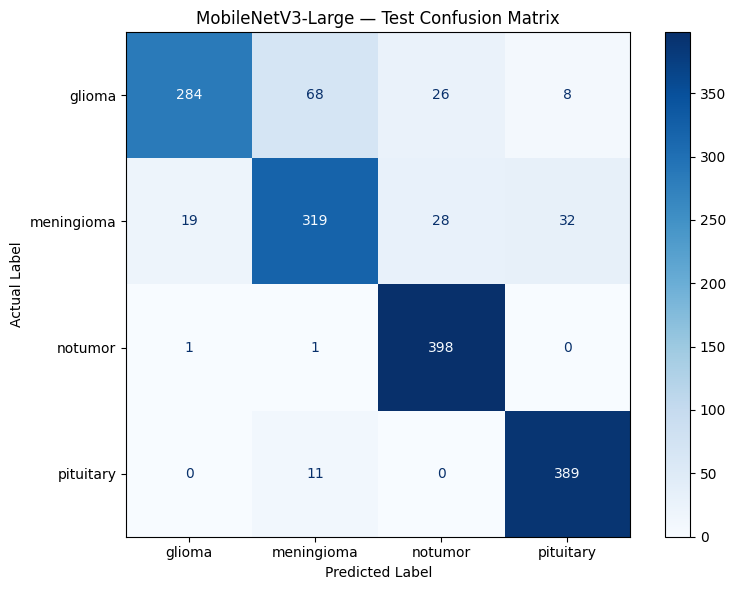

Confusion matrix saved to: ..\results\metrics\mobilenet_v3_large_confusion_matrix.png


In [6]:

# Step 6: Plot and save confusion matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

ax.set_title("MobileNetV3-Large — Test Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

plt.tight_layout()

confusion_matrix_path = (
    metrics_dir / "mobilenet_v3_large_confusion_matrix.png"
)

plt.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Confusion matrix saved to:", confusion_matrix_path)